# COGs file system indexation

**Living Earth - Cube in a Box Demo Series**

---

*   **Objective:** Prepare metadata and index existing COGs as a new product.
*   **COGs used:** Generated via [Sentinel_2.ipynb](Sentinel_2.ipynb), and available in `./cogs/`.

---

## Background

The notebook focuses on the task of preparing metadata and indexing existing COGs (Cloud Optimized Geospatial Files) as a new product.

## Description

The notebook automates the process of creating metadata for each COG file. It utilizes pre-defined templates and scripts to ensure that the metadata is consistent and accurately reflects the properties of each COG file. The metadata includes details such as the product name, file paths, and geospatial properties like the coordinate reference system (CRS) and bounding polygon.

Additionally, the notebook includes functionality to index these COGs, making them searchable and accessible through a datacube. This indexing process is essential for scaling up the handling and analysis of large geospatial datasets.

## Requirements

1. Single band COGs files (in our case `./cogs/` generated via [Sentinel_2.ipynb](Sentinel_2.ipynb))
2. Product definition yaml (in our case [s2_l2a_ndvi.odc-product.yaml](s2_l2a_ndvi.odc-product.yaml)
3. Metadata template (in our case) [template-metadata.yaml](template-metadata.yaml)

## Procedure

1. Adapt Product definition yaml and Metadata template to the COGs you want to index
2. Add new product definition
3. Generate metadata for each cogs folder
4. Transfer to destination folder
5. Index
6. Test

***

In [1]:
import sys
sys.path.insert(1, '../utils/')

In [2]:
# reload module before executing code
%load_ext autoreload
%autoreload 2

import datacube
import rioxarray
import time
import uuid

from datetime import datetime, timezone
from pathlib import Path

from utils.deafrica_plotting import rgb
from utils.le_cogs_to_filesystem import (
    add_dataset,
    add_product,
    describe_filesystem_image,
    extract_and_format_date,
    fill_template
)
from utils.le_dc import get_product_bbox
from utils.le_mapping import (
    bbox_to_polygon,
    display_crosshair,
    get_utm_epsg_code,
    MapHandler
)
from utils.le_tools import style_output_cells

In [3]:
cogs_folder = Path('./cogs/')
cogs_prfx = '*'

product_definition = 's2_l2a_ndvi.odc-product.yaml'

# Define static metadata variable
prod_prfx = 'S2_NDVI'
description = 'Sentinel-2 Weekly NDVI statistics'
instrument = 'MSI'
platform = 'Sentinel-2A'
band_names = ['ndvi_min', 'ndvi_mean', 'ndvi_max']

dest_folder = Path('/local_data')

## Add a new product definition

In our case [s2_l2a_ndvi.odc-product.yaml](s2_l2a_ndvi.odc-product.yaml):

```yaml
# source: https://raw.githubusercontent.com/digitalearthafrica/config/master/products/esa_s2_l2a.odc-product.yaml

---
name: s2_l2a_ndvi
description: NDVI from Sentinel-2a and Sentinel-2b imagery, processed to Level
  2A (Surface Reflectance) and converted to Cloud Optimized GeoTIFFs
metadata_type: eo3

metadata:
  product:
    name: s2_l2a_ndvi

measurements:
  - name: "ndvi_mean"
    aliases: [mean, average]
    units: "1"
    dtype: float32
    nodata: NaN
  - name: "ndvi_min"
    units: "1"
    dtype: float32
    nodata: NaN
  - name: "ndvi_max"
    units: "1"
    dtype: float32
    nodata: NaN
```

In [4]:
product = add_product(product_definition)

2026-04-01 12:11:17,687 781 datacube.index.postgres._products WARNING Product s2_l2a_ndvi is already in the database, checking for differences



# Create metadata.yamls

Using [template-metadata.yaml](template-metadata.yaml):
```yaml
$schema: https://schemas.opendatacube.org/dataset
id: <id>
label: <label>
product:
  name: <product>
crs: epsg:<crs>
geometry:
  type: Polygon
  coordinates: [[[<coordinates>]]]
grids:
  default:
    shape: [<shape>]
    transform: [<transform>]
properties:
  created: '<created>'
  datetime: '<dt>'
  description: '<description>'
  eo:gsd: '<gsd>'
  eo:instrument: '<instrument>'
  eo:platform: '<platform>'
  odc:processing_datetime: '<processing_datetime>'
  odc:product: '<product>'
  proj:epsg: '<epsg>'
  proj:shape:
  <shape>
  proj:transform:
  <transform>
measurements:
  <bands_dict>
lineage: {}
```

You need to build a dictionnary with all variables (`<variable>`) in this file.

**Notes:**
- ```yml
  shape: [<shape>]
  ```
  *will return e.g.*
  ``yml
  shape: [520, 560]
  ```
- ```yml
  proj:shape:
  <shape>
  ```
  *will return e.g.*
  ```yml
  proj:shape:
  - 520
  - 560
  ```

In [5]:
# General metadata
created = processing_datetime = datetime.now(timezone.utc).strftime("%Y-%m-%dT%H:%M:%SZ")
bands_dict = {b: {'path': b + '.tif'} for b in band_names}

# Scene metadata
cogs_dirs = [path for path in cogs_folder.glob(cogs_prfx) if path.is_dir()]
for cog_dir in cogs_dirs:
    label = f"{prod_prfx}_{cog_dir.name}"

    for cog_path in cog_dir.glob('*'):
        if cog_path.is_file() and cog_path.suffix.lower() in {'.tif', '.tiff'}:
            image_description = describe_filesystem_image(cog_path)
            crs = image_description['epsg_code']
            coordinates = image_description['polygon']
            shape = image_description['shape']
            transform = image_description['transform'][:6]
            gsd = transform[0]
        break

    values = {
        'id':                  str(uuid.uuid4()),
        'label':               label,
        'product':             product,
        'crs':                 crs,
        'coordinates':         coordinates,
        'shape':               list(shape),
        'transform':           list(transform),
        'created':             created,
        'dt':                  extract_and_format_date(label),
        'description':         description,
        'gsd':                 str(gsd),
        'instrument':          instrument,
        'platform':            platform,
        'processing_datetime': processing_datetime,
        'epsg':                str(crs),
        'bands_dict':          bands_dict,
        'accessories':         {},
    }

    metadata = fill_template(Path('template-metadata.yaml'), values)

    out_path = cog_dir / f"{prod_prfx}_metadata.yaml"
    out_path.write_text(fill_template(Path('template-metadata.yaml'), values))
    print(f"Written: {out_path}")

# Transfer to fs

In [6]:
import os
import shutil
yamls = []

for cog_dir in cogs_dirs:
    yaml_file = os.path.join(cog_dir, f"{prod_prfx}_metadata.yaml")
    if not os.path.exists(yaml_file):
        continue  # or raise an error / log a warning
    
    dest = os.path.join(dest_folder, product, os.path.basename(cog_dir))
    # shutil.copytree(cog_dir, dest, dirs_exist_ok=True)  # DEV
    shutil.move(cog_dir, dest)
    yamls.append(os.path.join(os.path.abspath(dest), f"{prod_prfx}_metadata.yaml"))

In [7]:
yamls

[]

# Index

In [8]:
newly_added, already_indexed, failed = add_dataset(yamls, max_workers=4)
    
print(f"\n{'='*60}")
print(f"Summary:")
print(f"  Newly added: {len(newly_added)}")
print(f"  Already indexed: {len(already_indexed)}")
print(f"  Failed: {len(failed)}")
print(f"  Total: {len(yamls)}")
print(f"{'='*60}")

Starting to add 0 datasets with 4 workers...

Completed: 0 newly added, 0 already indexed, 0 failed

Summary:
  Newly added: 0
  Already indexed: 0
  Failed: 0
  Total: 0


In [9]:
style_output_cells('salmon', border_color='red', border_width='2px')
print('Even if the dataset is now available from Jupyter Notebooks.\nYou need to ask the CiaB admin to update the Explorer !')

Even if the dataset is now available from Jupyter Notebooks.
You need to ask the CiaB admin to update the Explorer !


# Test Loading

In [10]:
dc = datacube.Datacube(app="cogs_fs_indexation")

In [11]:
# Check if default bbox is contained within the datacube
# and allow user to draw bbox if not.

# configure a default bounding box and visualize it
lat, lon = 22.821, 28.518
buffer = 0.05
default_bbox = (lon - buffer, lat - buffer, lon + buffer, lat + buffer)

product_bbox = get_product_bbox(dc, product, split_size=10, stability_threshold=4)

is_contained =(default_bbox[0] >= product_bbox[0] and
               default_bbox[1] >= product_bbox[1] and
               default_bbox[2] <= product_bbox[2] and
               default_bbox[3] <= product_bbox[3]
              )

In [12]:
# Create an instance of MapHandler
map_handler = MapHandler()
m, drc = map_handler.create_map(vect=[bbox_to_polygon(default_bbox), bbox_to_polygon(product_bbox)],
                               draw_rect=True)
display(m)

# append crosshair
time.sleep(2)  # make sure m is fully displayed
display_crosshair()

Map(center=[22.82094575026628, 28.51797775623696], controls=(AttributionControl(options=['position', 'prefix']…

<IPython.core.display.Javascript object>

In [13]:
# Warn in case of full AoI
aoi_poly = map_handler.aoi_tupple

if aoi_poly is None:
    aoi_poly = tuple(default_bbox)
    if not is_contained:
        style_output_cells('salmon', border_color='red', border_width='2px')
        print('The area of interest polygon is located outside of the product extent.' + \
              '\nPlease draw a new area of interest in the previous cell.')
    else:
        # When is_contained is True and no polygon drawn - this is actually OK!
        style_output_cells()
        print('Default area of interest is contained within the product extent, but you can still draw another one in the previous cell.')
else:
    # A polygon was drawn
    style_output_cells()
    print('Custom area of interest polygon has been created.')

Default area of interest is contained within the product extent, but you can still draw another one in the previous cell.


In [14]:
# get EPSG code for the center of the AoI

epsg_code = get_utm_epsg_code((aoi_poly[1] + aoi_poly[3]) / 2, (aoi_poly[0] + aoi_poly[2]) / 2)

In [15]:
dss = dc.find_datasets(product=product,
                       x=(aoi_poly[0], aoi_poly[2]),
                       y=(aoi_poly[1], aoi_poly[3]))
times = [ds.time.begin for ds in dss]
start_date = min(times)
end_date = max(times)

In [16]:
lazy_ds = dc.load(product=product,
                  measurements=band_names,
                  output_crs=f"EPSG:{epsg_code}",
                  y=(aoi_poly[1], aoi_poly[3]),
                  x=(aoi_poly[0], aoi_poly[2]),
                  time=(start_date.strftime('%Y-%m-%d'), end_date.strftime('%Y-%m-%d')),
                  resolution=30,
                  group_by="solar_day",
                  dask_chunks={},
                  )

In [17]:
# customized chunking is less buggy when performed after loading !!!
lazy_ds = lazy_ds.chunk({"x": 512, "y": 512, "time": 1})

# fix NotGeoreferencedWarning warning
lazy_ds.rio.write_crs(f"EPSG:{epsg_code}", inplace=False)

print(lazy_ds)

<xarray.Dataset> Size: 6MB
Dimensions:      (time: 4, y: 374, x: 347)
Coordinates:
  * time         (time) datetime64[ns] 32B 2021-12-05 2021-12-12 ... 2021-12-26
  * y            (y) float64 3kB 2.53e+06 2.53e+06 ... 2.519e+06 2.519e+06
  * x            (x) float64 3kB 6.506e+05 6.506e+05 ... 6.609e+05 6.61e+05
    spatial_ref  int32 4B 32635
Data variables:
    ndvi_min     (time, y, x) float32 2MB dask.array<chunksize=(1, 374, 347), meta=np.ndarray>
    ndvi_mean    (time, y, x) float32 2MB dask.array<chunksize=(1, 374, 347), meta=np.ndarray>
    ndvi_max     (time, y, x) float32 2MB dask.array<chunksize=(1, 374, 347), meta=np.ndarray>
Attributes:
    crs:           EPSG:32635
    grid_mapping:  spatial_ref


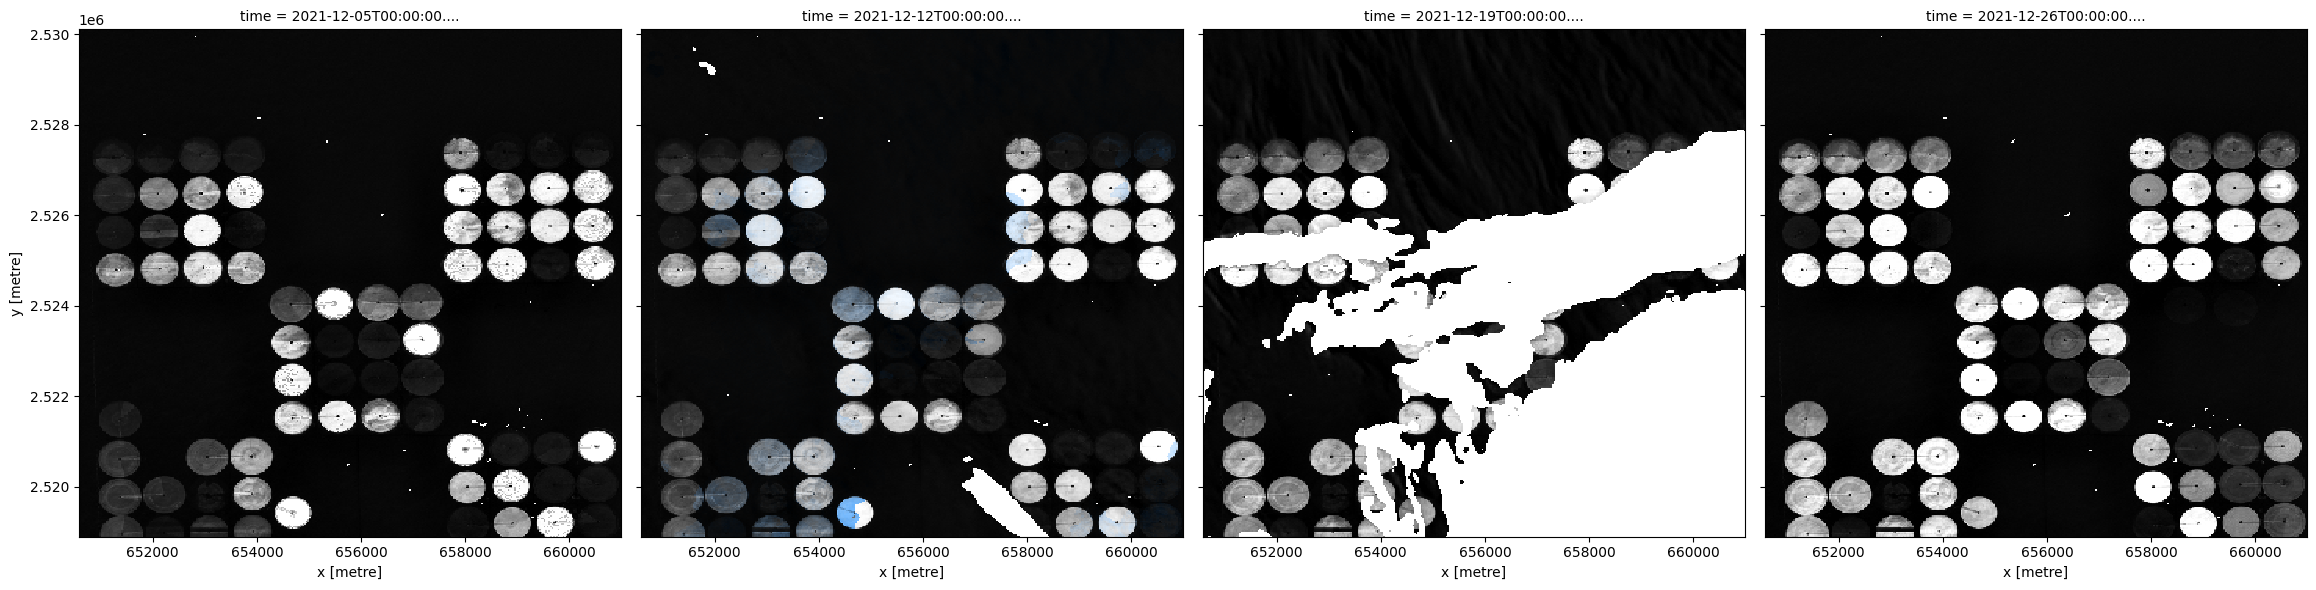

In [18]:
# Display a false color composite

rgb(lazy_ds, bands=band_names[:3], col="time", col_wrap=4, robust=True)

***

## Additional information

**License:** The code in this notebook is slighly modified from https://github.com/digitalearthafrica/deafrica-sandbox-notebooks and licensed under the [Apache License, Version 2.0](https://www.apache.org/licenses/LICENSE-2.0).

**Compatible datacube version:**

In [19]:
print(datacube.__version__)

1.9.14


**Last tested:**

In [20]:
from datetime import datetime
datetime.today().strftime('%Y-%m-%d')

'2026-04-01'

In [21]:
!pip freeze

affine==2.4.0
ai-edge-litert==2.1.2
aiobotocore==3.2.0
aiohappyeyeballs==2.6.1
aiohttp==3.13.3
aioitertools==0.13.0
aiosignal==1.4.0
alembic==1.18.4
annotated-types==0.7.0
antimeridian==0.4.4
anyio==4.12.1
argon2-cffi==25.1.0
argon2-cffi-bindings==25.1.0
arrow==1.4.0
asttokens==3.0.1
async-lru==2.2.0
attrs==25.4.0
babel==2.18.0
backports.strenum==1.2.8
beautifulsoup4==4.14.3
black==26.1.0
bleach==6.3.0
bokeh==3.8.2
boltons==25.0.0
boto3==1.42.55
botocore==1.42.55
branca==0.8.2
cachetools==7.0.1
cattrs==26.1.0
certifi==2026.2.25
certipy==0.2.2
cffi==2.0.0
cftime==1.6.5
charset-normalizer==3.4.4
ciso8601==2.3.3
click==8.3.1
click-plugins==1.1.1.2
cligj==0.7.2
cloudpickle==3.1.2
comm==0.2.3
contourpy==1.3.3
cryptography==46.0.5
cycler==0.12.1
dask==2025.7.0
dask-image==2025.11.0
dask_labextension==7.0.0
datacube==1.9.14
datadog==0.52.1
debugpy==1.8.20
decorator==5.2.1
defusedxml==0.7.1
deprecat==2.1.3
distributed==2025.7.0
eodatasets3==1.9.3
executing==2.2.1
fastjsonschema==2.21.2
fiona==